## TP - Les accidents en France 2022-2024

### Import des bibliothèques

In [1]:
#!pip install pandas

In [2]:
#!pip install matplotlib

In [3]:
#!pip install seaborn

In [4]:
#!pip install mlflow

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

import warnings
warnings.filterwarnings('ignore')

In [6]:
import sklearn 
print(f"veriosn de scikit learn : {sklearn.__version__}")

veriosn de scikit learn : 1.8.0


In [7]:
import warnings
warnings.filterwarnings('ignore')

## MLFlow settings

In [8]:
import mlflow 
import mlflow.sklearn

In [9]:
mlflow.set_tracking_uri("http://localhost:5000")
tracking_uri = mlflow.get_tracking_uri()

In [10]:
mlflow.set_experiment("my-first-experiment")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1771923153977, experiment_id='1', last_update_time=1771923153977, lifecycle_stage='active', name='my-first-experiment', tags={}, workspace='default'>

## Import des datasets 2022-2024 (lieux, vehicules, caract et usagers) & concaténation par type de fichier

In [11]:
#on crée les listes pour stocker les données par type de fichier
caract_list = []
lieux_list = []
vehicules_list = []
usagers_list = []

data_path = 'C:/Users/Utilisateur/Desktop/accidents/data'

#une boucle pour inporter les fichiers par an
for year in [2022, 2023, 2024]:
    caract_list.append(pd.read_csv(f'{data_path}/caract-{year}.csv', sep = ';', encoding = 'utf-8'))
    lieux_list.append(pd.read_csv(f'{data_path}/lieux-{year}.csv', sep = ';', encoding = 'utf-8'))
    vehicules_list.append(pd.read_csv(f'{data_path}/vehicules-{year}.csv', sep = ';', encoding = 'utf-8'))
    usagers_list.append(pd.read_csv(f'{data_path}/usagers-{year}.csv', sep = ';', encoding = 'utf-8'))

#concaténation des df
df_caract = pd.concat(caract_list, ignore_index = True)
df_lieux = pd.concat(lieux_list, ignore_index = True)
df_vehicules = pd.concat(vehicules_list, ignore_index = True)
df_usagers = pd.concat(usagers_list, ignore_index = True)

print(f"caract: {df_caract.shape}")
print(f"lieux: {df_lieux.shape}")
print(f"vehicules: {df_vehicules.shape}")
print(f"usagers: {df_usagers.shape}")

caract: (164526, 16)
lieux: (196410, 18)
vehicules: (280756, 11)
usagers: (377638, 16)


### Vérif rapide des structures des df

In [12]:
df_caract.head().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Accident_Id  5 non-null      float64
 1   jour         5 non-null      int64  
 2   mois         5 non-null      int64  
 3   an           5 non-null      int64  
 4   hrmn         5 non-null      object 
 5   lum          5 non-null      int64  
 6   dep          5 non-null      object 
 7   com          5 non-null      object 
 8   agg          5 non-null      int64  
 9   int          5 non-null      int64  
 10  atm          5 non-null      int64  
 11  col          5 non-null      int64  
 12  adr          5 non-null      object 
 13  lat          5 non-null      object 
 14  long         5 non-null      object 
 15  Num_Acc      0 non-null      float64
dtypes: float64(2), int64(8), object(6)
memory usage: 772.0+ bytes


In [13]:
df_caract.columns.tolist()

['Accident_Id',
 'jour',
 'mois',
 'an',
 'hrmn',
 'lum',
 'dep',
 'com',
 'agg',
 'int',
 'atm',
 'col',
 'adr',
 'lat',
 'long',
 'Num_Acc']

In [14]:
df_caract[['Accident_Id', 'Num_Acc']].head(5)

,Accident_Id,Num_Acc
0,2.022000e+11,NaN
1,2.022000e+11,NaN
2,2.022000e+11,NaN
3,2.022000e+11,NaN
4,2.022000e+11,NaN


In [15]:
df_lieux[['Num_Acc']].head(5)

,Num_Acc
0,202200000001
1,202200000002
2,202200000003
3,202200000004
4,202200000005


In [16]:
df_caract = df_caract.drop(columns = ['Num_Acc'])

In [17]:
df_caract = df_caract.rename(columns = {'Accident_Id': 'Num_Acc'})

In [18]:
df_caract['Num_Acc'] = df_caract['Num_Acc'].astype('Int64')

In [19]:
#vérif si c'est bon mtn 
df_caract[['Num_Acc']].head(5)

,Num_Acc
0,202200000001
1,202200000002
2,202200000003
3,202200000004
4,202200000005


In [20]:
df_lieux.head().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Num_Acc  5 non-null      int64 
 1   catr     5 non-null      int64 
 2   voie     4 non-null      object
 3   v1       5 non-null      int64 
 4   v2       0 non-null      object
 5   circ     5 non-null      int64 
 6   nbv      5 non-null      object
 7   vosp     5 non-null      int64 
 8   prof     5 non-null      int64 
 9   pr       5 non-null      object
 10  pr1      5 non-null      object
 11  plan     5 non-null      int64 
 12  lartpc   0 non-null      object
 13  larrout  5 non-null      object
 14  surf     5 non-null      int64 
 15  infra    5 non-null      int64 
 16  situ     5 non-null      int64 
 17  vma      5 non-null      int64 
dtypes: int64(11), object(7)
memory usage: 852.0+ bytes


In [21]:
df_vehicules.head().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Num_Acc      5 non-null      int64  
 1   id_vehicule  5 non-null      object 
 2   num_veh      5 non-null      object 
 3   senc         5 non-null      int64  
 4   catv         5 non-null      int64  
 5   obs          5 non-null      int64  
 6   obsm         5 non-null      int64  
 7   choc         5 non-null      int64  
 8   manv         5 non-null      int64  
 9   motor        5 non-null      int64  
 10  occutc       0 non-null      float64
dtypes: float64(1), int64(8), object(2)
memory usage: 572.0+ bytes


In [22]:
df_usagers.head().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Num_Acc      5 non-null      int64  
 1   id_usager    5 non-null      object 
 2   id_vehicule  5 non-null      object 
 3   num_veh      5 non-null      object 
 4   place        5 non-null      int64  
 5   catu         5 non-null      int64  
 6   grav         5 non-null      int64  
 7   sexe         5 non-null      int64  
 8   an_nais      5 non-null      float64
 9   trajet       5 non-null      int64  
 10  secu1        5 non-null      int64  
 11  secu2        5 non-null      int64  
 12  secu3        5 non-null      int64  
 13  locp         5 non-null      int64  
 14  actp         5 non-null      object 
 15  etatp        5 non-null      int64  
dtypes: float64(1), int64(11), object(4)
memory usage: 772.0+ bytes


### DFs merge selon l'hérarchie des données BAAC 

l'hiérarchie des données BAAC (Bases de données annuelles des accidents corporels) : 
accicent (caract + lieux) -> véhicule (1 accident peut avoir plusieurs véhicules) -> usager (un véhicule peut avoir plusieurs usagers)

In [23]:
#accicent (caract + lieux)
df = df_caract.merge(df_lieux, on = 'Num_Acc', how = 'left')
print(f"Après caract+lieux: {df.shape}")

Après caract+lieux: (164526, 32)


In [24]:
#rajout des véhicules
df = df.merge(df_vehicules, on = 'Num_Acc', how = 'left')
print(f"Après + vehicules: {df.shape}") 

Après + vehicules: (203717, 42)


In [25]:
#rajout des usagers
df = df.merge(df_usagers, on = ['Num_Acc', 'id_vehicule'], how  ='left')
print(f"DataFrame final: {df.shape}") 

DataFrame final: (235886, 56)


l'extrait de la doc BAAC: 
"Un véhicule peut être en fuite : 
Si un véhicule a un « id » dans la table « vehicule » mais qu’il n’est pas retrouvé dans la table « usagers » c’est qu’il s’agit d’un conducteur en fuite non créé dans la base. 
En général les conducteurs en fuite ne sont pas identifiés mais pour la base de données un conducteur virtuel sans info est créé, il arrive que le système ne les crée pas toujours".

il y aura donc une perte "naturelle" des données concernantes les véhicules en fuite: 

In [26]:
len(df_usagers)

377638

In [27]:
print(f"véhicules sans usagers (en fuite): {df['id_usager'].isna().sum()}")

véhicules sans usagers (en fuite): 109224


le nombre des véhicules en fuite semble significatif en présentant 25%+ de la masse totale des données. Hors, ce sont les véhicules inconnus, sans conducteur et sans info sur la gravité des blessures. 

dans le but de predire la gravite des futurs accidents, on ne peut pat utiliser les lignes où la var 'grav' est inconnue. --> on va entrainer le modèle sur les données complètes et confirmées. 

In [28]:
print(df['grav'].value_counts())
print(f"valeurs manquantes: {df['grav'].isna().sum()}")

grav
 1.0    53630
 4.0    49981
 3.0    19260
 2.0     3550
-1.0      241
Name: count, dtype: int64
valeurs manquantes: 109224


le nombre des véhicules en fuite est idem à celui des valeur manquantes dans la df. vu que ces lignes ne contiennent pas les données nécessaires pour l'entrainement du modèle, on les vire : 

In [29]:
df.shape

(235886, 56)

In [30]:
df_clean = df[df['id_usager'].notna()].copy()

In [31]:
df_clean.shape

(126662, 56)

## EDA & feature engeneering 

In [32]:
df_clean.info

<bound method DataFrame.info of              Num_Acc  jour  mois    an   hrmn  lum dep    com  agg  int  ...  \
0       202200000001    19    10  2022  16:15    1  26  26198    2    3  ...   
1       202200000001    19    10  2022  16:15    1  26  26198    2    3  ...   
2       202200000002    20    10  2022  08:34    1  25  25204    2    3  ...   
3       202200000002    20    10  2022  08:34    1  25  25204    2    3  ...   
4       202200000003    20    10  2022  17:15    1  22  22360    2    6  ...   
...              ...   ...   ...   ...    ...  ...  ..    ...  ...  ...  ...   
126657  202200055301     1     1  2022  08:40    1  81  81099    1    3  ...   
126658  202200055301     1     1  2022  08:40    1  81  81099    1    3  ...   
126659  202200055301     1     1  2022  08:40    1  81  81099    1    3  ...   
126660  202200055302     1     3  2022  16:55    1  41  41018    2    1  ...   
126661  202200055302     1     3  2022  16:55    1  41  41018    2    1  ...   

       

In [33]:
df_clean.columns.tolist()

['Num_Acc',
 'jour',
 'mois',
 'an',
 'hrmn',
 'lum',
 'dep',
 'com',
 'agg',
 'int',
 'atm',
 'col',
 'adr',
 'lat',
 'long',
 'catr',
 'voie',
 'v1',
 'v2',
 'circ',
 'nbv',
 'vosp',
 'prof',
 'pr',
 'pr1',
 'plan',
 'lartpc',
 'larrout',
 'surf',
 'infra',
 'situ',
 'vma',
 'id_vehicule',
 'num_veh_x',
 'senc',
 'catv',
 'obs',
 'obsm',
 'choc',
 'manv',
 'motor',
 'occutc',
 'id_usager',
 'num_veh_y',
 'place',
 'catu',
 'grav',
 'sexe',
 'an_nais',
 'trajet',
 'secu1',
 'secu2',
 'secu3',
 'locp',
 'actp',
 'etatp']

### target 

In [34]:
#on crée 2 groupes des blessures dans le 'grav'
df_clean['target'] = df_clean['grav'].apply(lambda x: 1 if x in [2,3] else 0)

In [35]:
print(df_clean['target'])

0         1
1         0
2         0
3         0
4         0
         ..
126657    0
126658    1
126659    0
126660    1
126661    0
Name: target, Length: 126662, dtype: int64


In [36]:
df_clean['target'].value_counts()

target
0    103852
1     22810
Name: count, dtype: int64

In [37]:
lines_total = len(df_clean)
lines_grave = df_clean['target'].sum()
lines_non_grave = lines_total - lines_grave

print(lines_non_grave)

103852


In [38]:
ratio = lines_non_grave / lines_grave

print(ratio)

4.552915387987725


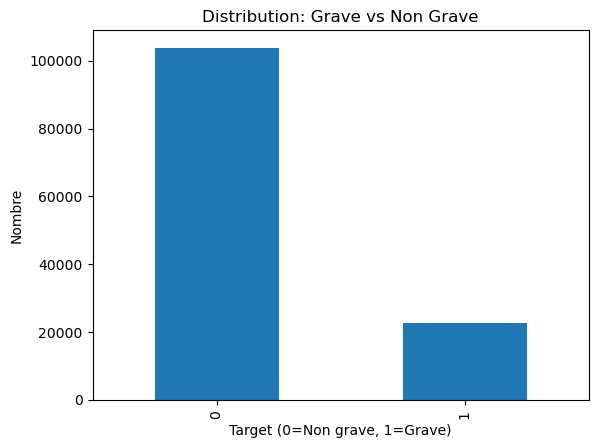

In [39]:
#visualisation de la target
df_clean['target'].value_counts().plot(kind='bar')
plt.title('Distribution: Grave vs Non Grave')
plt.xlabel('Target (0=Non grave, 1=Grave)')
plt.ylabel('Nombre')
plt.show()

### visualisation des patterns du temps 

#### par heure de la journée 

In [40]:
df_clean['heure'] = df_clean['hrmn'].str[:2].astype(int)

#proportion d'accidents graves par heure
gravite_par_heure = df_clean.groupby('heure')['target'].agg(['count', 'mean'])
gravite_par_heure.columns = ['Nb_accidents', 'Taux_grave']

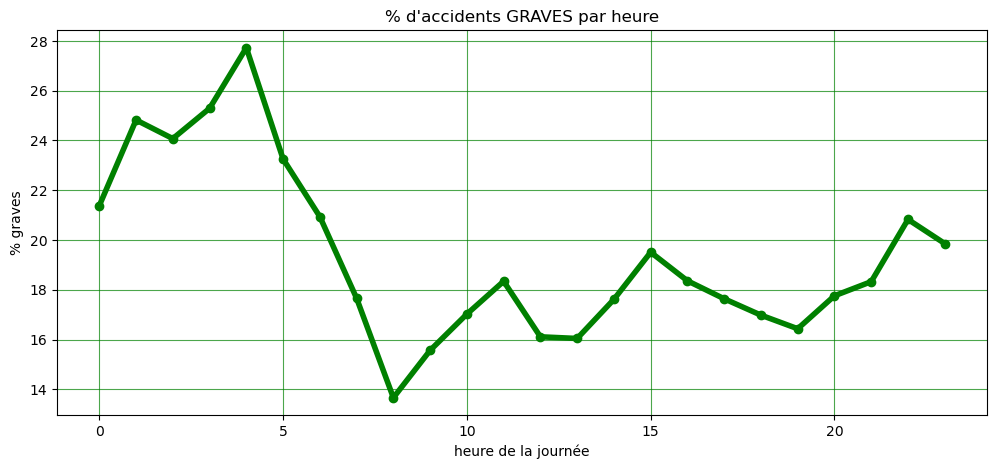

In [41]:
#visualisation de la gravité par heure de la journée
plt.figure(figsize=(12, 5))
plt.plot(gravite_par_heure.index, gravite_par_heure['Taux_grave'] * 100, 
         marker = 'o', linewidth = 4, color = 'green')
plt.title('% d\'accidents GRAVES par heure')
plt.xlabel('heure de la journée')
plt.ylabel('% graves')
plt.grid(alpha = 0.7, color = 'green')
plt.show()

#### par jour de la semaine 

In [42]:
#il faut créer la feature jour_semaine
df_clean['date'] = pd.to_datetime(df_clean[['an', 'mois', 'jour']].rename(columns = {'an': 'year', 'mois': 'month', 'jour': 'day'}))
df_clean['jour_semaine'] = df_clean['date'].dt.dayofweek #lundi c'est 0, dimanche c'est 6

gravite_par_jour = df_clean.groupby('jour_semaine')['target'].mean() * 100

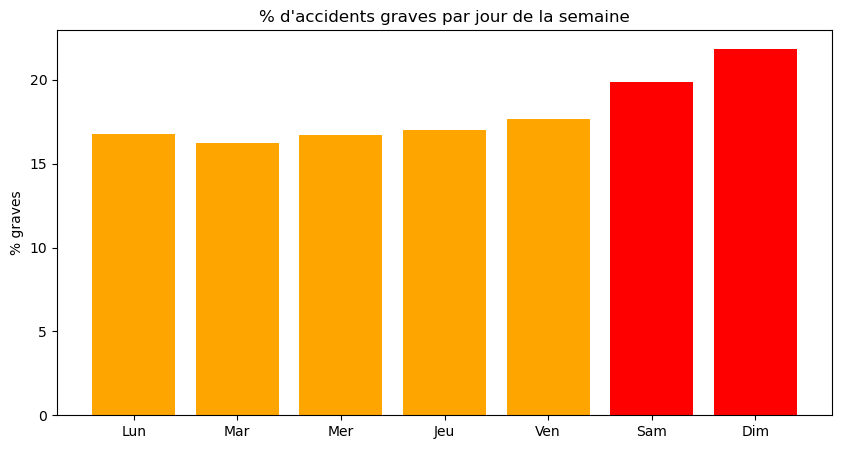

In [43]:
#visualisation de la gravité par jour de la semaine 
jours = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
plt.figure(figsize=(10, 5))
plt.bar(range(7), gravite_par_jour, color=['orange']*5 + ['red', 'red'])
plt.xticks(range(7), jours)
plt.title('% d\'accidents graves par jour de la semaine')
plt.ylabel('% graves')
plt.show()

### visualisation des variables importantes (celles qui infurencent la gravité des accidents)

#### la météo 

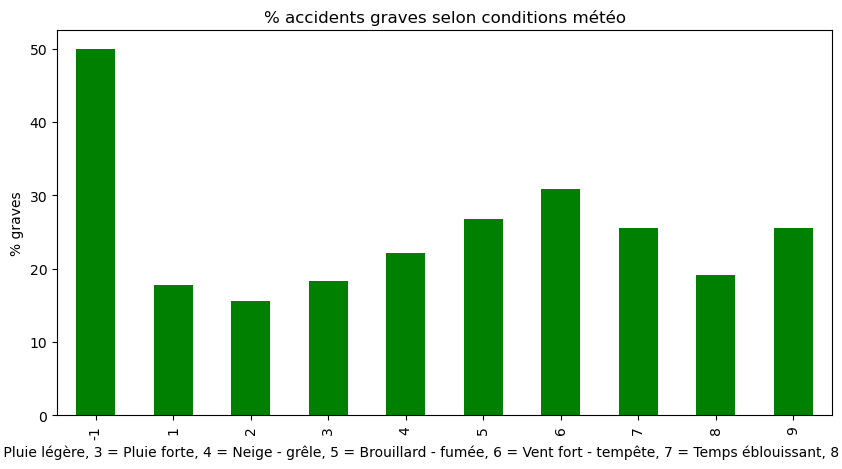

In [44]:
gravite_par_meteo = df_clean.groupby('atm')['target'].mean() * 100

plt.figure(figsize=(10, 5))
gravite_par_meteo.plot(kind = 'bar', color = 'green')
plt.title('% accidents graves selon conditions météo')
plt.xlabel('atm (1 = Normal, 2 = Pluie légère, 3 = Pluie forte, 4 = Neige - grêle, 5 = Brouillard - fumée, 6 = Vent fort - tempête, 7 = Temps éblouissant, 8 = Temps couvert, 9 = autre)')
plt.ylabel('% graves')
plt.show()

#### la lumière

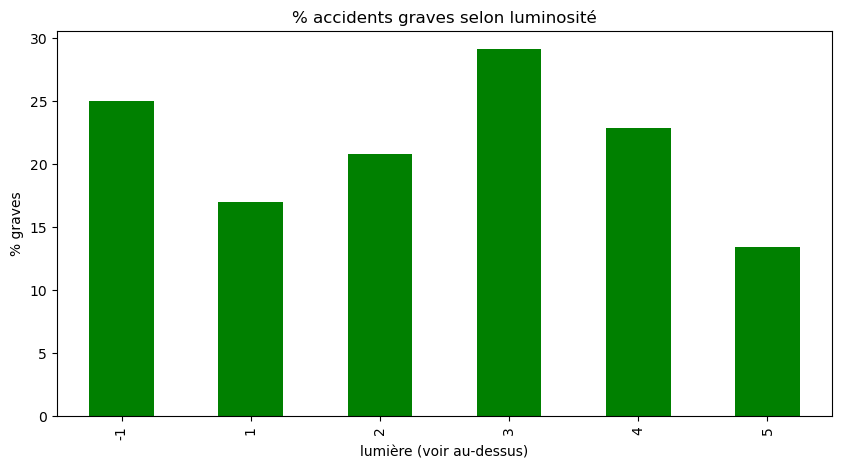

In [45]:
gravite_par_lum = df_clean.groupby('lum')['target'].mean() * 100

plt.figure(figsize=(10, 5))
gravite_par_lum.plot(kind = 'bar', color = 'green')
plt.title('% accidents graves selon luminosité')
plt.xlabel('lumière (voir au-dessus)')
plt.ylabel('% graves')
plt.show()

#### type de route

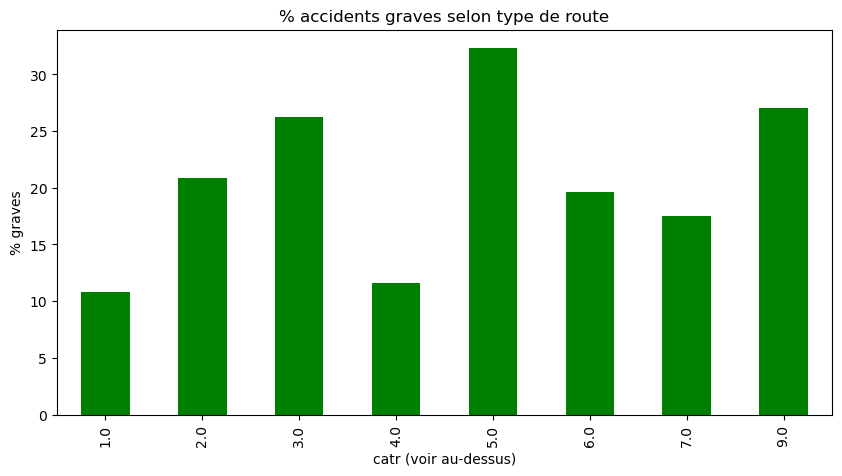

In [46]:
gravite_par_route = df_clean.groupby('catr')['target'].mean() * 100

plt.figure(figsize=(10, 5))
gravite_par_route.plot(kind = 'bar', color = 'green')
plt.title('% accidents graves selon type de route')
plt.xlabel('catr (voir au-dessus)')
plt.ylabel('% graves')
plt.show()

### âge des conducteurs

In [47]:
# on commence par la création de l'âge
df_clean['age'] = df_clean['an'] - df_clean['an_nais']
df_clean['age'] = df_clean['age'].clip(16, 100)  # on limite valeurs aberrantes

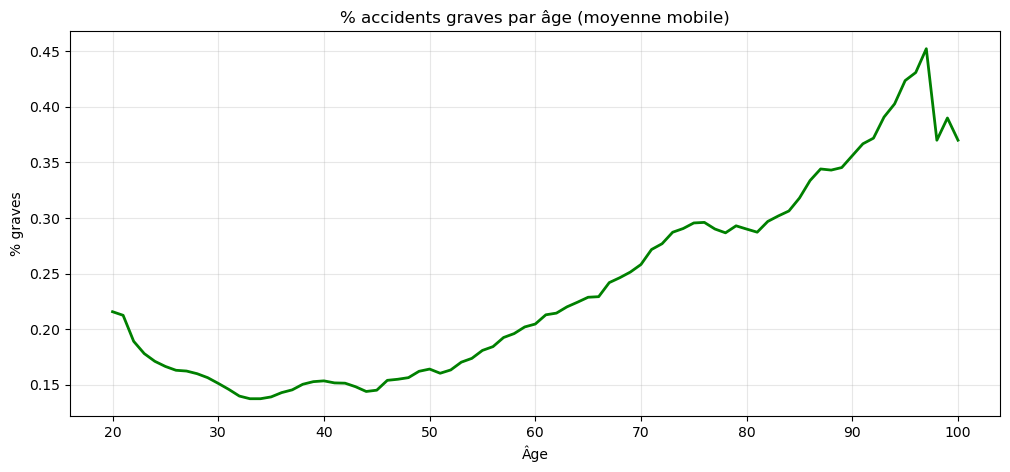

In [48]:
plt.figure(figsize=(12, 5))
df_clean.groupby('age')['target'].mean().rolling(5).mean().plot(linewidth=2, color = 'green')
plt.title('% accidents graves par âge (moyenne mobile)')
plt.xlabel('Âge')
plt.ylabel('% graves')
plt.grid(alpha=0.3)
plt.show()

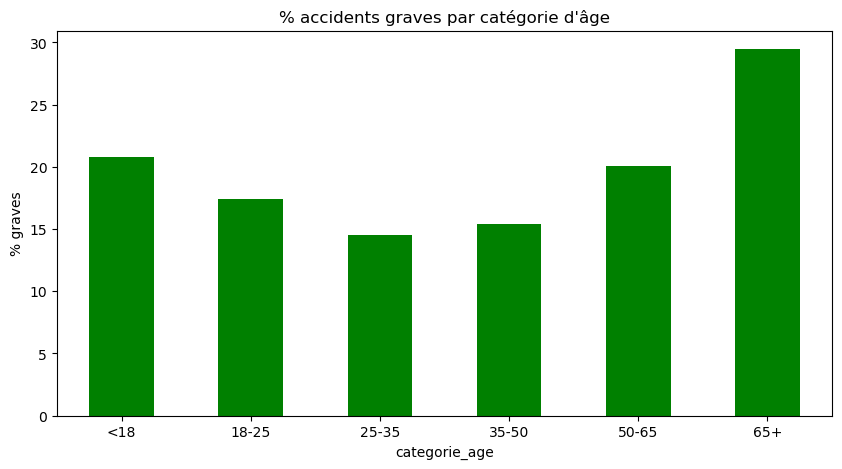

In [49]:
# Catégories d'âge
df_clean['categorie_age'] = pd.cut(df_clean['age'], 
                                    bins=[0, 18, 25, 35, 50, 65, 100],
                                    labels=['<18', '18-25', '25-35', '35-50', '50-65', '65+'])

gravite_par_age = df_clean.groupby('categorie_age')['target'].mean() * 100

plt.figure(figsize=(10, 5))
gravite_par_age.plot(kind='bar', color='green')
plt.title('% accidents graves par catégorie d\'âge')
plt.ylabel('% graves')
plt.xticks(rotation=0)
plt.show()

### les motos sont-elles plus dangereuses ?

In [50]:
vehicules_categories = {
    1: 'Vélo',
    2: 'Cyclo',
    7: 'Voiture',
    10: 'Utilitaire',
    31: 'Moto 50-125',
    33: 'Moto >125',
    37: 'Bus',
    # etc.
}

In [51]:
gravite_par_vehicule = df_clean.groupby('catv')['target'].agg(['mean', 'count'])
gravite_par_vehicule = gravite_par_vehicule[gravite_par_vehicule['count'] > 100]  # filtre les rares

gravite_par_vehicule['mean'] = gravite_par_vehicule['mean'] * 100
gravite_par_vehicule = gravite_par_vehicule.sort_values('mean', ascending=False).head(10)

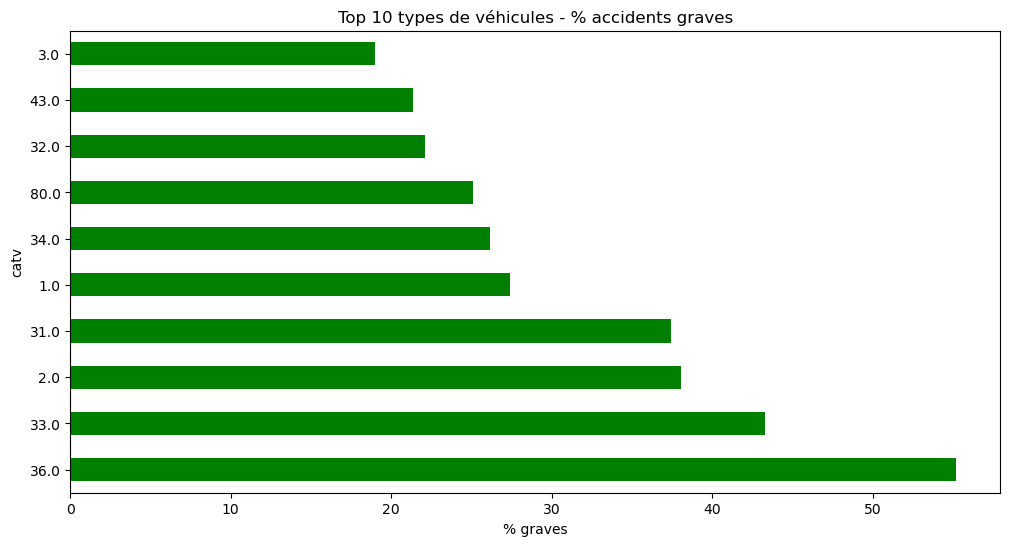

In [52]:
plt.figure(figsize=(12, 6))
gravite_par_vehicule['mean'].plot(kind = 'barh', color = 'green')
plt.title('Top 10 types de véhicules - % accidents graves')
plt.xlabel('% graves')
plt.show()

In [53]:
print("""Traduction des résultats: 
1. 36 – Quad lourd > 50 cm3 (Quadricycle à moteur non carrossé)
2. 33 – Motocyclette > 125 cm3
3. 02 – Cyclomoteur <50cm3
4. 31 – Motocyclette > 50 cm3 et <= 125 cm3
5. 01 – Bicyclette 
6. 34 – Scooter > 125 cm3
7. 80 – VAE 
8. 32 – Scooter > 50 cm3 et <= 125 cm3
9. 43 – 3RM > 125 cm3
10. 03 – Voiturette (Quadricycle à moteur carrossé) (anciennement "voiturette ou tricycle à moteur")
""")

Traduction des résultats: 
1. 36 – Quad lourd > 50 cm3 (Quadricycle à moteur non carrossé)
2. 33 – Motocyclette > 125 cm3
3. 02 – Cyclomoteur <50cm3
4. 31 – Motocyclette > 50 cm3 et <= 125 cm3
5. 01 – Bicyclette 
6. 34 – Scooter > 125 cm3
7. 80 – VAE 
8. 32 – Scooter > 50 cm3 et <= 125 cm3
9. 43 – 3RM > 125 cm3
10. 03 – Voiturette (Quadricycle à moteur carrossé) (anciennement "voiturette ou tricycle à moteur")



## features engineering (transformation des données en info utiles pour le modèle)

In [54]:
# Features temporelles
df_clean['heure'] = df_clean['hrmn'].str[:2].astype(int)
df_clean['date'] = pd.to_datetime(df_clean[['an', 'mois', 'jour']].rename(columns = {'an': 'year', 'mois': 'month', 'jour': 'day'}))
df_clean['jour_semaine'] = df_clean['date'].dt.dayofweek #0 = lundi, 6 = dimanche
df_clean['weekend'] = (df_clean['jour_semaine'] >= 5).astype(int) #5 = samedi, 6 = dimanche, le résultat qui est de base True or False devient 1 ou 0 pour le modèle

# création d'une var 'nuit' qui comprend le temps entre 22h et 6h
df_clean['nuit'] = ((df_clean['heure'] >= 22) | (df_clean['heure'] <= 6)).astype(int)

# âge des usagers
df_clean['age'] = df_clean['an'] - df_clean['an_nais']
df_clean['age'] = df_clean['age'].clip(16, 100) #limite les valeurs aberrantes pour que tout les a^ges soient entre 16 et 100 ans (erreurs de saisie des données)
df_clean['jeune_conducteur'] = (df_clean['age'] < 25).astype(int)

# les conditions dangereuses de la doc BAAC (les conditions seront reconnues comme dangereuses si au moins 1 des ci-dessous est VRAIE, c'est plus simple pour le modèle)
df_clean['conditions_danger'] = (
    (df_clean['atm'].isin([2, 3, 4, 5, 6])) |  # mauvais temps
    (df_clean['lum'].isin([3, 4])) |           # nuit sans éclairage
    (df_clean['surf'].isin([2, 3, 4, 7]))      # chaussée glissante
).astype(int)

print(df_clean[['heure', 'nuit', 'jour_semaine', 'age', 'conditions_danger', 'jeune_conducteur']].head(5))

   heure  nuit  jour_semaine   age  conditions_danger  jeune_conducteur
0     16     0             2  16.0                  0                 1
1     16     0             2  74.0                  0                 0
2      8     0             3  34.0                  0                 0
3      8     0             3  52.0                  0                 0
4     17     0             3  20.0                  0                 1


## Prépa avant le split

### vérif des valeurs manquantes

In [55]:
missing = df_clean.isnull().sum()
missing = missing[missing > 0].sort_values(ascending = False)

print(missing)

lartpc           126599
occutc           124892
v2               114769
voie               9885
adr                2875
an_nais            2874
age                2874
categorie_age      2874
dtype: int64


In [56]:
df_clean['voie'] = df_clean['voie'].fillna('Inconnu')

In [57]:
df_clean = df_clean.drop(columns = ['adr'])

In [58]:
age_median = df_clean['age'].median()
df_clean['age'] = df_clean['age'].fillna(age_median)

print(age_median)

35.0


In [59]:
#recréer la col 'jeune_conducteur'
df_clean['jeune_conducteur'] = (df_clean['age'] < 25).astype(int)

print(df_clean['jeune_conducteur'])

0         1
1         0
2         0
3         0
4         1
         ..
126657    1
126658    1
126659    0
126660    0
126661    1
Name: jeune_conducteur, Length: 126662, dtype: int32


In [60]:
df_clean.shape

(126662, 65)

In [61]:
df_clean.isnull().sum()

Num_Acc                 0
jour                    0
mois                    0
an                      0
hrmn                    0
                     ... 
categorie_age        2874
weekend                 0
nuit                    0
jeune_conducteur        0
conditions_danger       0
Length: 65, dtype: int64

### sélection des col utiles pour le modèle 

In [62]:
df_clean.columns.tolist()

['Num_Acc',
 'jour',
 'mois',
 'an',
 'hrmn',
 'lum',
 'dep',
 'com',
 'agg',
 'int',
 'atm',
 'col',
 'lat',
 'long',
 'catr',
 'voie',
 'v1',
 'v2',
 'circ',
 'nbv',
 'vosp',
 'prof',
 'pr',
 'pr1',
 'plan',
 'lartpc',
 'larrout',
 'surf',
 'infra',
 'situ',
 'vma',
 'id_vehicule',
 'num_veh_x',
 'senc',
 'catv',
 'obs',
 'obsm',
 'choc',
 'manv',
 'motor',
 'occutc',
 'id_usager',
 'num_veh_y',
 'place',
 'catu',
 'grav',
 'sexe',
 'an_nais',
 'trajet',
 'secu1',
 'secu2',
 'secu3',
 'locp',
 'actp',
 'etatp',
 'target',
 'heure',
 'date',
 'jour_semaine',
 'age',
 'categorie_age',
 'weekend',
 'nuit',
 'jeune_conducteur',
 'conditions_danger']

In [63]:
features_a_garder = [
    'heure', 'jour_semaine', 'weekend', 'nuit', 'mois', #temps
    'lum', 'atm', 'col', 'agg', 'int', #météo
    'catr', 'circ', 'nbv', 'prof', 'plan', 'surf', 'infra', 'situ', 'vma', #route
    'catv', 'obs', 'obsm', 'choc', 'manv', 'motor', #véhicule
    'catu', 'sexe', 'age', 'trajet', 'secu1', 'place', #usager
    'jeune_conducteur', 'conditions_dangereuses', #new
    'target'
]

In [64]:
features_disponibles = [f for f in features_a_garder if f in df_clean.columns]

print(f"Features disponibles: {len(features_disponibles)}/{len(features_a_garder)}")

Features disponibles: 33/34


In [65]:
df_model = df_clean[features_disponibles].copy()

In [66]:
df_model.shape

(126662, 33)

### traitement des valeurs textuelles

In [67]:
df_model.dtypes.value_counts()

float64    20
int64       7
int32       5
object      1
Name: count, dtype: int64

In [68]:
from sklearn.preprocessing import LabelEncoder

In [69]:
colonnes_cat = df_model.select_dtypes(include = ['object']).columns.tolist()

print(colonnes_cat)

['nbv']


In [70]:
for col in colonnes_cat: 
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

### séparation de la target (y) du reste (x)

In [71]:
X = df_model.drop('target', axis=1)
y = df_model['target']

print(f"\nNaN dans X: {X.isnull().sum().sum()}")
print(f"NaN dans y: {y.isnull().sum()}")


NaN dans X: 0
NaN dans y: 0


## Split train & test

In [72]:
from sklearn.model_selection import train_test_split

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42, stratify = y)

In [74]:
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

# le ratio 
print(f"\n% graves dans y (total):  {y.mean()*100:.2f}%")
print(f"% graves dans y_train:    {y_train.mean()*100:.2f}%")
print(f"% graves dans y_test:     {y_test.mean()*100:.2f}%")

X_train: (94996, 32)
X_test:  (31666, 32)
y_train: (94996,)
y_test:  (31666,)

% graves dans y (total):  18.01%
% graves dans y_train:    18.01%
% graves dans y_test:     18.01%


In [75]:
X_train.dtypes.value_counts()

float64    20
int32       6
int64       6
Name: count, dtype: int64

## Modélisation

### logistic regression

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, recall_score

In [77]:
with mlflow.start_run(run_name = "LogReg"):

    model_lr = LogisticRegression(
        class_weight = 'balanced', 
        max_iter = 1000, 
        random_state = 42
    )
    #mlflow.log_param("model_type", "LogisticRegression")
    #mlflow.log_param("class_weight", "balanced") 
    #mlflow.log_param("max_iter", 1000)
    #mlflow.log_param("random_state", 42)

    mlflow.log_param("params", model_lr.get_params()) #on remplace les paramètres rentrés à la main ci-dessus
    
    model_lr.fit(X_train, y_train)
    y_pred_lr = model_lr.predict(X_test)

    acc = accuracy_score(y_test, y_pred_lr)
    recall = recall_score(y_test, y_pred_lr)

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("recall", recall)

    mlflow.sklearn.log_model(model_lr, "pick")

print(classification_report(y_test, y_pred_lr))

2026/02/26 14:14:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 14:14:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LogReg at: http://localhost:5000/#/experiments/1/runs/b6f542ab049342cba23470c1b1ef43a8
🧪 View experiment at: http://localhost:5000/#/experiments/1
              precision    recall  f1-score   support

           0       0.90      0.69      0.79     25963
           1       0.32      0.67      0.44      5703

    accuracy                           0.69     31666
   macro avg       0.61      0.68      0.61     31666
weighted avg       0.80      0.69      0.72     31666



In [78]:
mlflow.sklearn.autolog()

with mlflow.start_run(run_name = "LogRegAuto"):

    model_lr = LogisticRegression(
            class_weight = 'balanced', 
            max_iter = 1000, 
            random_state = 42
        )
        
    model_lr.fit(X_train, y_train)
    y_pred_lr = model_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

2026/02/26 14:15:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LogRegAuto at: http://localhost:5000/#/experiments/1/runs/3650ba8d80af4ea1b828423cf57cb9f2
🧪 View experiment at: http://localhost:5000/#/experiments/1
              precision    recall  f1-score   support

           0       0.90      0.69      0.79     25963
           1       0.32      0.67      0.44      5703

    accuracy                           0.69     31666
   macro avg       0.61      0.68      0.61     31666
weighted avg       0.80      0.69      0.72     31666



NB : "macro avg"  param à rajouter si plus que 2 classes à prédire

### random forest

In [79]:
from sklearn.ensemble import RandomForestClassifier

In [80]:
mlflow.sklearn.autolog()

with mlflow.start_run(run_name = "RanForAuto"):
    
    model_rf = RandomForestClassifier(
        max_depth = 10,
        n_estimators = 100,
        class_weight = 'balanced',
        random_state = 42,
        n_jobs = -1
    )
    model_rf.fit(X_train, y_train)
    y_pred_rf = model_rf.predict(X_test)


2026/02/26 14:15:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RanForAuto at: http://localhost:5000/#/experiments/1/runs/b3365e3109c146be905d44e4c68039c0
🧪 View experiment at: http://localhost:5000/#/experiments/1


## MLFlow boucle des modèles

In [81]:
models = {
    "RandomForest" : RandomForestClassifier(
        max_depth = 10,
        n_estimators = 100,
        class_weight = 'balanced',
        random_state = 42,
        n_jobs = -1
    ), 
    "LogisticRegression" : LogisticRegression(
        class_weight = 'balanced', 
        max_iter = 1000, 
        random_state = 42
    )
}

In [82]:
mlflow.sklearn.autolog(serialization_format="skops")

for key, value in models.items():
    with mlflow.start_run(run_name = f"{key}"):
        value.fit(X_train, y_train)
        y_pred_mlflow = value.predict(X_test)

        print(classification_report(y_test, y_pred_mlflow))

2026/02/26 14:15:54 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmph4d1zswt\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 


              precision    recall  f1-score   support

           0       0.94      0.76      0.84     25963
           1       0.42      0.78      0.54      5703

    accuracy                           0.76     31666
   macro avg       0.68      0.77      0.69     31666
weighted avg       0.85      0.76      0.79     31666

🏃 View run RandomForest at: http://localhost:5000/#/experiments/1/runs/ed0f1026aa6b460f8362bcb02f645cb2
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/02/26 14:16:16 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmp7jsh0hes\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 


              precision    recall  f1-score   support

           0       0.90      0.69      0.79     25963
           1       0.32      0.67      0.44      5703

    accuracy                           0.69     31666
   macro avg       0.61      0.68      0.61     31666
weighted avg       0.80      0.69      0.72     31666

🏃 View run LogisticRegression at: http://localhost:5000/#/experiments/1/runs/99b7f39084a94ad494cf482ed6432261
🧪 View experiment at: http://localhost:5000/#/experiments/1


### MLFlow 2e experiment : tuning-xgboost

In [83]:
#!pip install xgboost

In [84]:
from xgboost import XGBClassifier

In [85]:
mlflow.set_experiment("Tuning Random Forest")

<Experiment: artifact_location='mlflow-artifacts:/6', creation_time=1771945344559, experiment_id='6', last_update_time=1771945344559, lifecycle_stage='active', name='Tuning Random Forest', tags={}, workspace='default'>

the best configuration du model

In [86]:
from sklearn.metrics import (confusion_matrix, classification_report)
import seaborn as sns

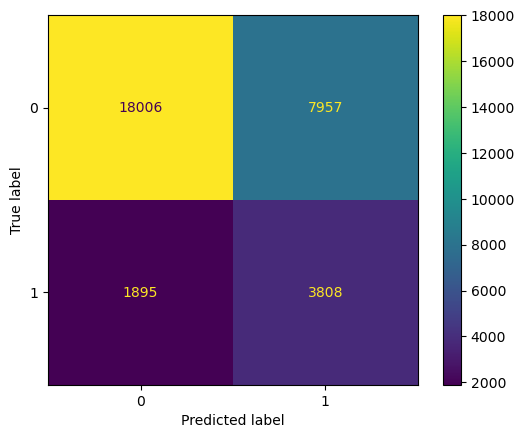

In [87]:
from sklearn import metrics

confusion_matrix = metrics.confusion_matrix(y_test, y_pred_mlflow)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

2026/02/26 14:16:27 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmp2_b7_4jw\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 
2026/02/26 14:16:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 14:16:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run XGBoost_try1 at: http://localhost:5000/#/experiments/6/runs/1cb48333200a49e4abb78f1865a365de
🧪 View experiment at: http://localhost:5000/#/experiments/6


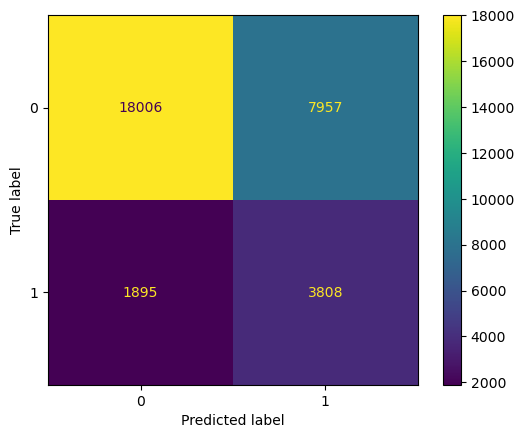

In [88]:
from sklearn import metrics

confusion_matrix = metrics.confusion_matrix(y_test, y_pred_mlflow)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.savefig("confusion_matrix22.png")
#plt.close(confusion_matrix) # Close the plot to free memory

with mlflow.start_run(run_name = "XGBoost_try1"):
    model = RandomForestClassifier(
        max_depth = 100, 
        n_estimators = 10, 
        class_weight = 'balanced', 
        random_state = 42, 
        min_samples_leaf = 5 
    )
    model.fit(X_train, y_train)
    y_pred_mlflow = model.predict(X_test)

    mlflow.log_params(model.get_params())

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("recall", recall)

    mlflow.sklearn.log_model(model, "boost_try")

    mlflow.log_artifact("confusion_matrix22.png")

In [89]:
with mlflow.start_run(run_name = "XGBoost_try2"):
    model = RandomForestClassifier(
        max_depth = 2, 
        n_estimators = 100, 
        class_weight = 'balanced_subsample', 
        random_state = 42, 
        min_samples_leaf = 1 
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mlflow.log_params(model.get_params())

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("recall", recall)

    mlflow.sklearn.log_model(model, "boost_try")   

2026/02/26 14:16:52 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmp_f2s4c42\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 
2026/02/26 14:16:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 14:16:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run XGBoost_try2 at: http://localhost:5000/#/experiments/6/runs/9de37be02cc64782b8feb4a673f81500
🧪 View experiment at: http://localhost:5000/#/experiments/6


In [90]:
with mlflow.start_run(run_name = "XGBoost_try3"):
    model = RandomForestClassifier(
        criterion = "entropy", 
        n_estimators = 400, 
        max_depth = 8, 
        oob_score = True, 
        verbose = 1,
        class_weight = 'balanced_subsample', 
        random_state = 42, 
        min_samples_leaf = 3 
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mlflow.log_params(model.get_params())

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("recall", recall)

    mlflow.sklearn.log_model(model, "boost_try")  

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    3.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   13.9s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
2026/02/26 14:17:49 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmpwkvmxapm\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    

🏃 View run XGBoost_try3 at: http://localhost:5000/#/experiments/6/runs/4769d3aaad284b87a0deadb6e9d13353
🧪 View experiment at: http://localhost:5000/#/experiments/6


In [91]:
mlflow.end_run()

In [92]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.4s


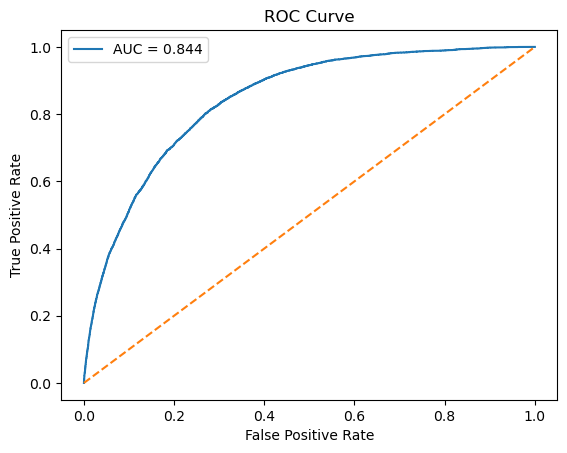

In [93]:
# Probabilités classe positive
y_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve.png")

In [94]:
import json

feature_names = list(X_train.columns)

with open("feature_names.json", "w") as f:
    json.dump(feature_names, f)

In [95]:
with mlflow.start_run(run_name = "XGBoost_try4"):
    model = RandomForestClassifier(
        criterion = "entropy", 
        n_estimators = 400, 
        max_depth = 8, 
        oob_score = True, 
        verbose = 1,
        class_weight = 'balanced_subsample', 
        random_state = 42, 
        min_samples_leaf = 3 
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mlflow.log_params(model.get_params())

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("recall", recall)

    mlflow.log_artifact("roc_curve.png")
    mlflow.log_artifact("feature_names.json")
    mlflow.log_params( # Log version metadata
            {
            "data_size": len(df_clean),
            "features_count": len(df_clean.columns) - 1,
            "target_distribution": df_clean["target"].value_counts(normalize = True),
            }
        ) 
    mlflow.sklearn.log_model(model, "boost_try", registered_model_name="sk-learn-random-forest-model") 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    3.4s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   14.3s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
2026/02/26 14:19:08 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmptxsnn424\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    

🏃 View run XGBoost_try4 at: http://localhost:5000/#/experiments/6/runs/524ccd4b85e645bca0999cbd2f0d4356
🧪 View experiment at: http://localhost:5000/#/experiments/6


une autre façon d'enregister le modèle: mlflow.registermodel(modeluri, "nom-du-modele")

### MLFlow client

In [96]:
from mlflow import MlflowClient
client = MlflowClient()

In [97]:
import mlflow 
client = mlflow.tracking.MlflowClient()
runs = client.search_runs(6, "", order_by=["metrics.roc_auc ASC"], max_results=1)
best_run = runs[0]

best_run

<Run: data=<RunData: metrics={'accuracy': 0.688877660582328,
 'recall': 0.6677187445204279,
 'training_accuracy_score': 0.7569055539180597,
 'training_f1_score': 0.7819803390198153,
 'training_log_loss': 0.4958871473973283,
 'training_precision_score': 0.849179489757733,
 'training_recall_score': 0.7569055539180597,
 'training_roc_auc': 0.8583743266486079,
 'training_score': 0.7569055539180597}, params={'bootstrap': 'True',
 'ccp_alpha': '0.0',
 'class_weight': 'balanced_subsample',
 'criterion': 'entropy',
 'data_size': '126662',
 'features_count': '64',
 'max_depth': '8',
 'max_features': 'sqrt',
 'max_leaf_nodes': 'None',
 'max_samples': 'None',
 'min_impurity_decrease': '0.0',
 'min_samples_leaf': '3',
 'min_samples_split': '2',
 'min_weight_fraction_leaf': '0.0',
 'monotonic_cst': 'None',
 'n_estimators': '400',
 'n_jobs': 'None',
 'oob_score': 'True',
 'random_state': '42',
 'target_distribution': 'target\n'
                        '0    0.819914\n'
                        '1    

In [98]:
print("Run ID:", best_run.info.run_id)
print("Run name:", best_run.data.tags.get("mlflow.runName"))
print("Metrics:", best_run.data.metrics)
print("Params:", best_run.data.params)

Run ID: 524ccd4b85e645bca0999cbd2f0d4356
Run name: XGBoost_try4
Metrics: {'training_precision_score': 0.849179489757733, 'training_recall_score': 0.7569055539180597, 'training_f1_score': 0.7819803390198153, 'training_accuracy_score': 0.7569055539180597, 'training_log_loss': 0.4958871473973283, 'training_roc_auc': 0.8583743266486079, 'training_score': 0.7569055539180597, 'accuracy': 0.688877660582328, 'recall': 0.6677187445204279}
Params: {'bootstrap': 'True', 'ccp_alpha': '0.0', 'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'max_depth': '8', 'max_features': 'sqrt', 'max_leaf_nodes': 'None', 'max_samples': 'None', 'min_impurity_decrease': '0.0', 'min_samples_leaf': '3', 'min_samples_split': '2', 'min_weight_fraction_leaf': '0.0', 'monotonic_cst': 'None', 'n_estimators': '400', 'n_jobs': 'None', 'oob_score': 'True', 'random_state': '42', 'verbose': '1', 'warm_start': 'False', 'data_size': '126662', 'features_count': '64', 'target_distribution': 'target\n0    0.819914\n1  

## GridSearchCV + MLflow

In [99]:
from sklearn.model_selection import GridSearchCV

In [100]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [101]:
modelGrid = RandomForestClassifier(random_state = 42)
grid_search = GridSearchCV(
    estimator=modelGrid,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

In [102]:
grid_search.fit(X_train, y_train)

2026/02/26 14:19:42 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3a600e070a9f4f3db6781e9d8c4aeccf', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Fitting 5 folds for each of 108 candidates, totalling 540 fits


2026/02/26 15:00:41 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['sklearn.metrics._classification.accuracy_score', 'sklearn.metrics._scorer._Scorer'].


🏃 View run industrious-goat-909 at: http://localhost:5000/#/experiments/6/runs/3a600e070a9f4f3db6781e9d8c4aeccf
🧪 View experiment at: http://localhost:5000/#/experiments/6


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [103]:
best_model=grid_search.best_estimator_
y_pred=best_model.predict(X_test) 

In [104]:
# Print results
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print(f"Test set score: {grid_search.score(X_test, y_test):.4f}")

Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score: 0.8545
Test set score: 0.8518


In [105]:
# Calculate total combinations
total_combinations = 1
for param in param_grid.values():
    total_combinations *= len(param)
print(f"Total parameter combinations evaluated: {total_combinations}")

Total parameter combinations evaluated: 108


## Optuna + MLflow

In [106]:
#!pip install optuna

In [107]:
#!pip install optuna-integration[mlflow]

In [108]:
import optuna
from optuna.integration.mlflow import MLflowCallback
from datetime import datetime

In [109]:
mlflc = MLflowCallback(
    tracking_uri=tracking_uri,
    metric_name="recall",
)

### Optuna : Recall score 

In [110]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    recall = recall_score(y_test, y_pred)

    return recall

In [111]:
date_run = datetime.now().strftime("%Y%m%d%H%M%S")

study = optuna.create_study(
    direction="maximize",
    study_name=f"RandomForest{date_run}"
)

study.optimize(objective, n_trials=4)

[I 2026-02-26 15:00:45,547] A new study created in memory with name: RandomForest20260226150045
2026/02/26 15:00:45 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '98bb8e1753064ca0b849a5ef2ee30dae', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/26 15:01:11 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmpoblv4mbh\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 


🏃 View run aged-mole-470 at: http://localhost:5000/#/experiments/6/runs/98bb8e1753064ca0b849a5ef2ee30dae
🧪 View experiment at: http://localhost:5000/#/experiments/6


[I 2026-02-26 15:01:29,718] Trial 0 finished with value: 0.2237418902332106 and parameters: {'n_estimators': 193, 'max_depth': 9}. Best is trial 0 with value: 0.2237418902332106.
2026/02/26 15:01:29 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '34655570aa504f7ea4a4af389d2fea19', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/26 15:02:12 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmpp6btinri\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 


🏃 View run trusting-hound-865 at: http://localhost:5000/#/experiments/6/runs/34655570aa504f7ea4a4af389d2fea19
🧪 View experiment at: http://localhost:5000/#/experiments/6


[I 2026-02-26 15:03:20,925] Trial 1 finished with value: 0.3257934420480449 and parameters: {'n_estimators': 243, 'max_depth': 17}. Best is trial 1 with value: 0.3257934420480449.
2026/02/26 15:03:20 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd6130a46419d433f9a5d2737c1288c6a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/26 15:03:38 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmp2_sklrph\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 


🏃 View run illustrious-gull-975 at: http://localhost:5000/#/experiments/6/runs/d6130a46419d433f9a5d2737c1288c6a
🧪 View experiment at: http://localhost:5000/#/experiments/6


[I 2026-02-26 15:03:50,610] Trial 2 finished with value: 0.21585130633000174 and parameters: {'n_estimators': 75, 'max_depth': 9}. Best is trial 1 with value: 0.3257934420480449.
2026/02/26 15:03:50 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9ec6a7e8d33b4e07b0a37cbd51a12da7', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/26 15:04:12 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmpye8ejdnz\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 


🏃 View run awesome-worm-228 at: http://localhost:5000/#/experiments/6/runs/9ec6a7e8d33b4e07b0a37cbd51a12da7
🧪 View experiment at: http://localhost:5000/#/experiments/6


[I 2026-02-26 15:04:28,161] Trial 3 finished with value: 0.26003857618797127 and parameters: {'n_estimators': 117, 'max_depth': 11}. Best is trial 1 with value: 0.3257934420480449.


In [112]:
print(recall)

0.6677187445204279


### Optuna : F1 score 

In [113]:
from sklearn.metrics import f1_score

In [116]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)

    return f1

In [117]:
date_run = datetime.now().strftime("%Y%m%d%H%M%S")

study = optuna.create_study(
    direction="maximize",
    study_name=f"RandomForest{date_run}"
)

study.optimize(objective, n_trials=10)

[I 2026-02-26 15:39:45,842] A new study created in memory with name: RandomForest20260226153945
2026/02/26 15:39:47 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a448fb7187ff4da78493969b0e8393de', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/26 15:40:15 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmpacxiattj\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 


🏃 View run skittish-chimp-211 at: http://localhost:5000/#/experiments/6/runs/a448fb7187ff4da78493969b0e8393de
🧪 View experiment at: http://localhost:5000/#/experiments/6


[I 2026-02-26 15:40:35,724] Trial 0 finished with value: 0.2946144261387235 and parameters: {'n_estimators': 267, 'max_depth': 8}. Best is trial 0 with value: 0.2946144261387235.
2026/02/26 15:40:35 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd25f823cd74141e895cddd060aca7596', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/26 15:40:58 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmp2_mmtur8\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 


🏃 View run puzzled-bass-700 at: http://localhost:5000/#/experiments/6/runs/d25f823cd74141e895cddd060aca7596
🧪 View experiment at: http://localhost:5000/#/experiments/6


[I 2026-02-26 15:41:20,982] Trial 1 finished with value: 0.44287894798638017 and parameters: {'n_estimators': 90, 'max_depth': 18}. Best is trial 1 with value: 0.44287894798638017.
2026/02/26 15:41:21 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9f6bc544acd640ac848b760a934f9149', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/26 15:41:44 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmpvbthf9lw\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 


...

[I 2026-02-26 15:48:05,002] Trial 7 finished with value: 0.4468506228897427 and parameters: {'n_estimators': 104, 'max_depth': 19}. Best is trial 3 with value: 0.4500117068602201.
2026/02/26 15:48:05 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '5504ec8109d344b1b549bd3f5642208e', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/26 15:48:38 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmpy7b8c0ax\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 


🏃 View run worried-stoat-68 at: http://localhost:5000/#/experiments/6/runs/5504ec8109d344b1b549bd3f5642208e
🧪 View experiment at: http://localhost:5000/#/experiments/6


[I 2026-02-26 15:49:09,686] Trial 8 finished with value: 0.4060448408274495 and parameters: {'n_estimators': 244, 'max_depth': 13}. Best is trial 3 with value: 0.4500117068602201.
2026/02/26 15:49:09 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '316055b680a94f0d829872b30a962195', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/26 15:49:45 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmpr5ilwh4r\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 


🏃 View run respected-shoat-646 at: http://localhost:5000/#/experiments/6/runs/316055b680a94f0d829872b30a962195
🧪 View experiment at: http://localhost:5000/#/experiments/6


[I 2026-02-26 15:50:28,395] Trial 9 finished with value: 0.428743961352657 and parameters: {'n_estimators': 239, 'max_depth': 15}. Best is trial 3 with value: 0.4500117068602201.


In [122]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred)

0.4485345838218054

In [118]:
print(f1_score)

<function f1_score at 0x0000019F8C34B380>


In [119]:
print(study.best_params)
print(study.best_trial)
print(study.best_value) 

{'n_estimators': 219, 'max_depth': 18}
FrozenTrial(number=3, state=<TrialState.COMPLETE: 1>, values=[0.4500117068602201], datetime_start=datetime.datetime(2026, 2, 26, 15, 42, 3, 553794), datetime_complete=datetime.datetime(2026, 2, 26, 15, 43, 48, 98314), params={'n_estimators': 219, 'max_depth': 18}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=300, log=False, low=50, step=1), 'max_depth': IntDistribution(high=20, log=False, low=2, step=1)}, trial_id=3, value=None)
0.4500117068602201


In [120]:
best_param = study.best_params
model = RandomForestClassifier(**best_param, random_state=42)
model.fit(X_train, y_train)

2026/02/26 15:50:28 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '1295ced7892a45c0877b53f28d2333bb', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/02/26 15:51:06 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\UTILIS~1\AppData\Local\Temp\tmpx5mgguk1\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'skops==0.13.0']. Set logging level to DEBUG to see the full traceback. 


🏃 View run vaunted-horse-58 at: http://localhost:5000/#/experiments/6/runs/1295ced7892a45c0877b53f28d2333bb
🧪 View experiment at: http://localhost:5000/#/experiments/6


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",219
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",18
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

##  Comparaison des modèles (optionnel) : 

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
    ],
    'Recall (Grave)': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
    ]
})

print(results)

# Features importantes (Random Forest)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 features importantes:")
print(feature_importance.head(10))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matrice de confusion pour Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion - Logistic Regression')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.xticks([0.5, 1.5], ['Non Grave', 'Grave'])
plt.yticks([0.5, 1.5], ['Non Grave', 'Grave'])
plt.show()

# Interprétation
print("Lecture de la matrice :")
print(f"Vrais Négatifs (Non grave → Non grave): {cm_lr[0,0]}")
print(f"Faux Positifs (Non grave → Grave):      {cm_lr[0,1]}")
print(f"Faux Négatifs (Grave → Non grave):      {cm_lr[1,0]}")
print(f"Vrais Positifs (Grave → Grave):         {cm_lr[1,1]}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Données
categories = ['VN\n(Bien)', 'FP\n(Fausse alerte)', 'FN\n(Grave manqué)', 'VP\n(Bien)']
valeurs = [18006, 7957, 1895, 3808]
couleurs = ['green', 'orange', 'red', 'darkgreen']

# Graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, valeurs, color=couleurs, alpha=0.7)

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, valeurs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{val:,}', ha='center', fontsize=12, fontweight='bold')

plt.title('Répartition des prédictions - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Nombre de cas', fontsize=12)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Pourcentages
total = sum(valeurs)

print(f"Vrais Négatifs:  {valeurs[0]/total*100:.1f}%")
print(f"Faux Positifs:   {valeurs[1]/total*100:.1f}%  ← Fausses alertes")
print(f"Faux Négatifs:   {valeurs[2]/total*100:.1f}%  ← Graves manqués")
print(f"Vrais Positifs:  {valeurs[3]/total*100:.1f}%")

### on save le model

In [ ]:
import joblib
import os

In [ ]:
model_path = 'C:\\Users\\Utilisateur\\Desktop\\accidents\\backend\\model_pred'

In [ ]:
joblib.dump(model_lr, f'{model_path}/model_logistic_regression.pkl')

In [ ]:
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

In [ ]:
#saugarde du modèle au cas ou 
joblib.dump(model_rf, f'{model_path}/model_random_forest.pkl')

## Création de l'API

In [ ]:
#!pip install fastapi uvicorn

In [ ]:
code_api = '''from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI(title = "API Prédiction Accidents")

model = joblib.load('model_logistic_regression.pkl')
columns = joblib.load('model_columns.pkl')

@app.get("/")
def home(): 
    return{"message": "API marche", "status" : "OK"}

@app.get("/health")
def health():
    return{"status": "healthy", "model": "Logistic Regression"}

@app.post("/predict")
def predict(heure: int = 14, lum: int = 1, atm: int = 1, age: float = 30, 
            catr: int = 3, agg: int = 2, sexe: int = 1, catv: int = 7):

    data = {col: 0 for col in columns} #le dictionnaire avec les colonnes vides à 0
    
#on rajoute les vealurs dans le dictionnaire
    data['heure'] = heure
    data['lum'] = lum
    data['atm'] = atm
    data['age'] = age
    data['catr'] = catr
    data['agg'] = agg
    data['sexe'] = sexe
    data['catv'] = catv
    
#on calcule les features supplem. 
    data['nuit'] = 1 if (heure >= 22 or heure <= 6) else 0
    data['jeune_conducteur'] = 1 if age < 25 else 0
    data['conditions_dangereuses'] = 1 if (atm in [2,3,4,5,6] or lum in [3,4]) else 0
    
#on crée une df 
    df = pd.DataFrame([data])[columns]
    
#le prédiction 
    prediction = int(model.predict(df)[0])
    proba = model.predict_proba(df)[0]
    
    return {
        "gravite": "Grave" if prediction == 1 else "Non grave",
        "probabilite_grave": round(float(proba[1]) * 100, 1),
        "probabilite_non_grave": round(float(proba[0]) * 100, 1)
    }
'''

with open('api.py', 'w', encoding='utf-8') as f:
    f.write(code_api)

print("le fichier api.py est créé")

## Création de l'interface avec Streamlite

In [ ]:
code_streamlit = '''import streamlit as st
import requests
import json

# Configuration de la page
st.set_page_config(
    page_title="Prédiction Accidents",
    layout="centered"
)

# Titre
st.title("Prédiction de Gravité d'Accident")
st.markdown("---")

# Informations sur le modèle
with st.expander("À propos du modèle utilisé"):
    st.write("""
    **Modèle :** Logistic Regression  
    **Recall (Graves) :** 66.8%  
    **Dataset :** Accidents 2022-2024 (126,662 usagers)
    
    Le modèle prédit si un accident sera **grave** (hospitalisé ou tué) ou **non grave** (indemne ou blessé léger).
    """)

st.markdown("---")

# Formulaire de saisie
st.subheader("Caractéristiques de l'accident selon BAAC")

col1, col2 = st.columns(2)

with col1:
    heure = st.slider("Heure de l'accident", 0, 23, 14, 
                      help="Heure de la journée (0-23h)")
    
    lum = st.selectbox("Luminosité", 
                       options=[1, 2, 3, 4, 5],
                       format_func=lambda x: {
                           1: "Plein jour",
                           2: "Crépuscule/aube",
                           3: "Nuit sans éclairage",
                           4: "Nuit éclairage non allumé",
                           5: "Nuit éclairage allumé"
                       }[x])
    
    atm = st.selectbox("Conditions météo",
                       options=[1, 2, 3, 4, 5, 6],
                       format_func=lambda x: {
                           1: "Normale",
                           2: "Pluie légère",
                           3: "Pluie forte",
                           4: "Neige/grêle",
                           5: "Brouillard",
                           6: "Vent fort"
                       }[x])
    
    age = st.slider("Âge du conducteur", 16, 100, 30)

with col2:
    catr = st.selectbox("Type de route",
                        options=[1, 2, 3, 4],
                        format_func=lambda x: {
                            1: "Autoroute",
                            2: "Route nationale",
                            3: "Route départementale",
                            4: "Voie communale"
                        }[x])
    
    agg = st.selectbox("Localisation",
                       options=[1, 2],
                       format_func=lambda x: {
                           1: "Hors agglomération",
                           2: "En agglomération"
                       }[x])
    
    sexe = st.selectbox("Sexe",
                        options=[1, 2],
                        format_func=lambda x: {
                            1: "Masculin",
                            2: "Féminin"
                        }[x])
    
    catv = st.selectbox("Type de véhicule",
                        options=[1, 2, 7, 10, 31, 33],
                        format_func=lambda x: {
                            1: "Vélo",
                            2: "Cyclomoteur",
                            7: "Voiture",
                            10: "Utilitaire",
                            31: "Moto 50-125cc",
                            33: "Moto >125cc"
                        }[x],
                        index=2)

st.markdown("---")

# Bouton de prédiction
if st.button("Prédire la gravité de l'accident", type="primary", use_container_width=True):
    
    with st.spinner("Prédiction en cours..."):
        try:
            # Appeler l'API
            url = "http://127.0.0.1:8000/predict"
            params = {
                "heure": heure,
                "lum": lum,
                "atm": atm,
                "age": age,
                "catr": catr,
                "agg": agg,
                "sexe": sexe,
                "catv": catv
            }
            
            response = requests.post(url, params=params)
            
            if response.status_code == 200:
                result = response.json()
                
                # Afficher le résultat
                st.markdown("---")
                st.subheader("Résultat de la prédiction")
                
                gravite = result["gravite"]
                proba_grave = result["probabilite_grave"]
                proba_non_grave = result["probabilite_non_grave"]
                
                # Affichage avec couleur selon la gravité
                if gravite == "Grave":
                    st.error(f"### ⚠️ ACCIDENT GRAVE")
                    st.metric("Probabilité d'accident grave", f"{proba_grave}%")
                    st.warning("Mobiliser des secours importants immédiatement")
                else:
                    st.success(f"### Accident non grave")
                    st.metric("Probabilité d'accident non grave", f"{proba_non_grave}%")
                    st.info("Intervention standard suffisante")
                
                # Détails
                with st.expander("Voir les détails"):
                    col_a, col_b = st.columns(2)
                    with col_a:
                        st.metric("Probabilité Non Grave", f"{proba_non_grave}%")
                    with col_b:
                        st.metric("Probabilité Grave", f"{proba_grave}%")
                    
                    # Barre de progression
                    st.progress(proba_grave / 100)
                    
                    # Contexte
                    st.write("**Contexte de l'accident :**")
                    nuit = "Oui" if (heure >= 22 or heure <= 6) else "Non"
                    jeune = "Oui" if age < 25 else "Non"
                    conditions = "Oui" if (atm in [2,3,4,5,6] or lum in [3,4]) else "Non"
                    
                    st.write(f"- Nuit : {nuit}")
                    st.write(f"- Jeune conducteur (<25 ans) : {jeune}")
                    st.write(f"- Conditions dangereuses : {conditions}")
                
            else:
                st.error(f"Erreur API : {response.status_code}")
                
        except requests.exceptions.ConnectionError:
            st.error("**Erreur de connexion à l'API**")
            st.info("Assurez-vous que l'API est lancée avec : `uvicorn api:app --reload`")
        except Exception as e:
            st.error(f"Erreur : {str(e)}")

# Footer
st.markdown("---")
st.caption("Projet ML - Prédiction Accidents Routiers | Données BAAC 2022-2024")
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(code_streamlit)

print("fichier app.py streamlit créé")
